In [1]:
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))

In [4]:
# Convert column to string and strip extra spaces
df["Heart Disease"] = df["Heart Disease"].astype(str).str.strip()
# Remove leading/trailing spaces and standardize
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [6]:
# Define features and target variable ,we'll use only numerical features for simplicity and the most correlated ones with our target variable
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42, stratify=y)

In [8]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 504000
Testing samples: 126000


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Test Accuracy: 0.8022


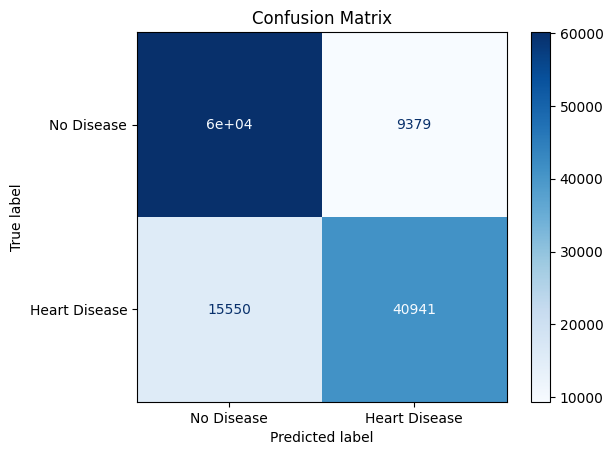

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.79      0.87      0.83     69509
Heart Disease       0.81      0.72      0.77     56491

     accuracy                           0.80    126000
    macro avg       0.80      0.79      0.80    126000
 weighted avg       0.80      0.80      0.80    126000



C:\Users\MSI\AppData\Local\Temp\ipykernel_19400\2146112085.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")


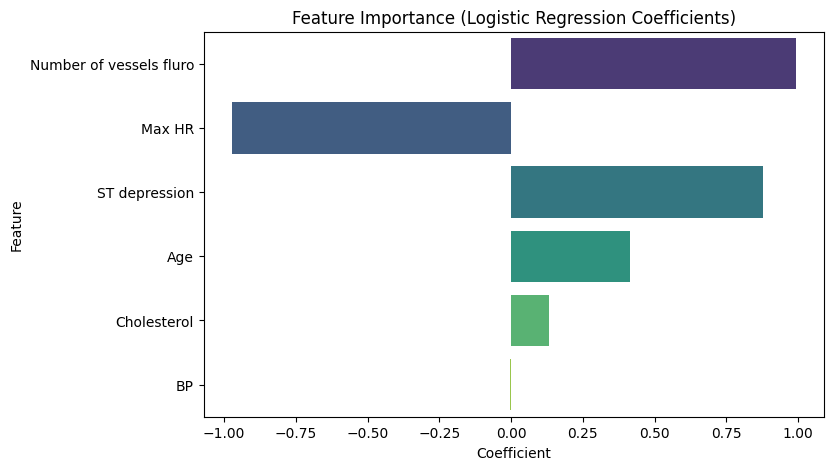

In [18]:
# 4️⃣ Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5️⃣ Predict on test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]  # probability for positive class

# 6️⃣ Evaluate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 7️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 8️⃣ Classification Report (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# 9️⃣ Optional: Feature Importance (coefficients)
feature_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mean CV Accuracy: 0.8008


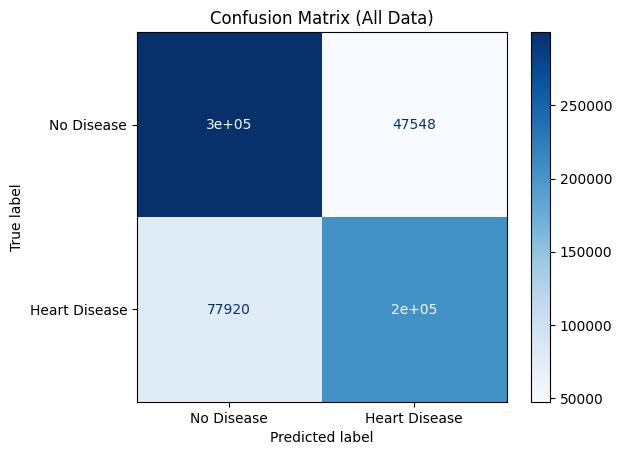

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.79      0.86      0.83    347546
Heart Disease       0.81      0.72      0.77    282454

     accuracy                           0.80    630000
    macro avg       0.80      0.79      0.80    630000
 weighted avg       0.80      0.80      0.80    630000



C:\Users\MSI\AppData\Local\Temp\ipykernel_19400\195113020.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")


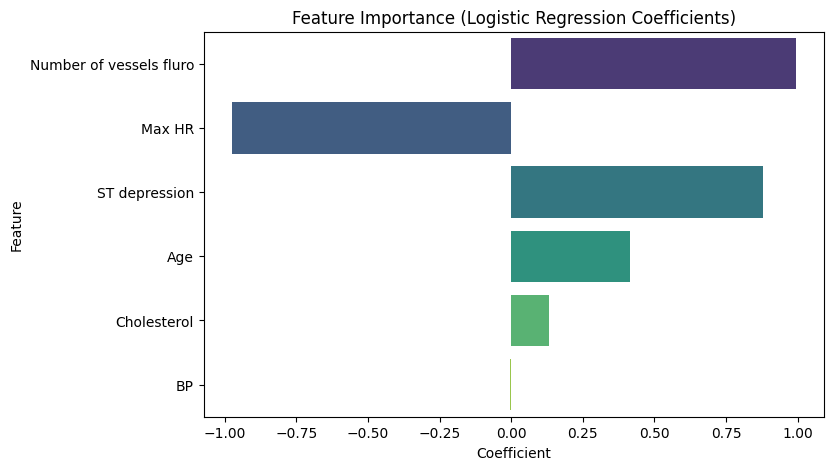

In [19]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Define Logistic Regression and parameter grid
logreg = LogisticRegression(random_state=42, max_iter=1000)
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],   # Regularization strength
    "penalty": ["l2"],               # L2 regularization (default)
    "solver": ["lbfgs"]
}

# 4️⃣ Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5️⃣ GridSearchCV with cross-validation
grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_scaled, y)

# 6️⃣ Best hyperparameters and score
print("Best Hyperparameters:", grid.best_params_)
print(f"Mean CV Accuracy: {grid.best_score_:.4f}")

# 7️⃣ Evaluate on the same data (or split if you want separate test set)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_scaled)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (All Data)")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y, y_pred, target_names=["No Disease", "Heart Disease"]))

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

5-Fold CV Accuracy Scores: [0.79805556 0.79930556 0.80077381 0.79763889 0.80113095]
Mean CV Accuracy: 0.7994

Test Accuracy: 0.8015


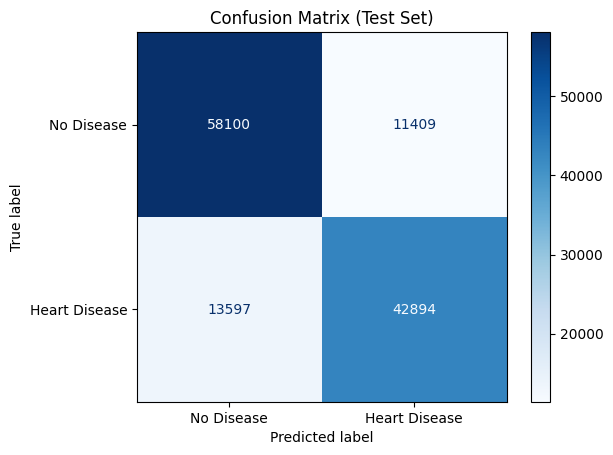


Classification Report (Test Set):
               precision    recall  f1-score   support

   No Disease       0.81      0.84      0.82     69509
Heart Disease       0.79      0.76      0.77     56491

     accuracy                           0.80    126000
    macro avg       0.80      0.80      0.80    126000
 weighted avg       0.80      0.80      0.80    126000



C:\Users\MSI\AppData\Local\Temp\ipykernel_19400\3658825381.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")


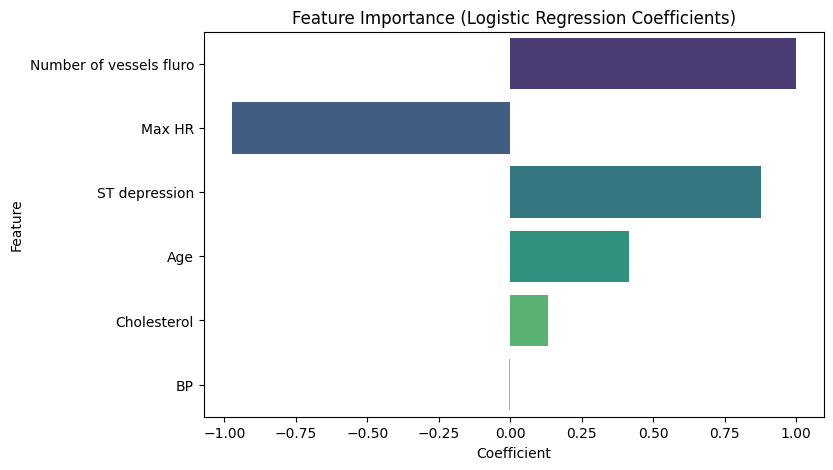

In [20]:
# -----------------------------
# Logistic Regression with class_weight="balanced" + k-fold CV
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1️⃣ Features and target
# -----------------------------
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Split into train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Standardize features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4️⃣ Define Logistic Regression with class_weight balanced
# -----------------------------
model = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)

# -----------------------------
# 5️⃣ Stratified K-Fold Cross-Validation
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# -----------------------------
# 6️⃣ Train on full training set
# -----------------------------
model.fit(X_train_scaled, y_train)

# -----------------------------
# 7️⃣ Evaluate on test set
# -----------------------------
y_pred = model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# -----------------------------
# 8️⃣ Feature Importance (Coefficients)
# -----------------------------
feature_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

In [ ]:
# -----------------------------
# SVM Classifier with class_weight balanced + k-fold CV
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# 6️⃣ Train on full training set
svm_model.fit(X_train_scaled, y_train)

# 7️⃣ Evaluate on test set
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

In [1]:
# -----------------------------
# SVM Classifier (single train/test split)
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay



In [11]:
# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")


Training samples: 504000
Testing samples: 126000
Class distribution in training set:
Heart Disease
0    278037
1    225963
Name: count, dtype: int64


In [ ]:
# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Train SVM on training set
svm_model.fit(X_train_scaled, y_train)

# 6️⃣ Predict on test set
y_pred = svm_model.predict(X_test_scaled)

# 7️⃣ Evaluate
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.1min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.8s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    8.9s finished


Random Forest Test Accuracy: 0.7864


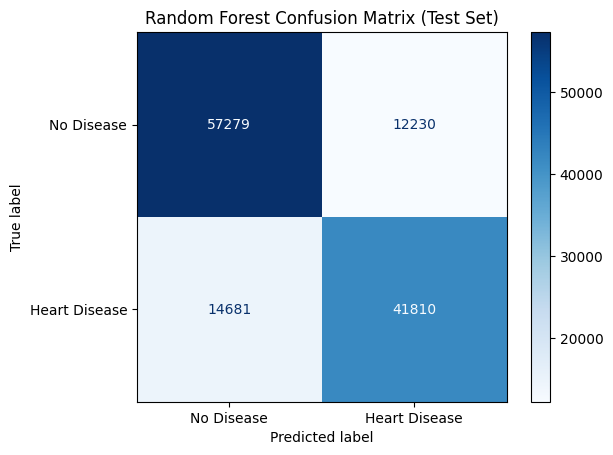


Classification Report (Test Set):
               precision    recall  f1-score   support

   No Disease       0.80      0.82      0.81     69509
Heart Disease       0.77      0.74      0.76     56491

     accuracy                           0.79    126000
    macro avg       0.78      0.78      0.78    126000
 weighted avg       0.79      0.79      0.79    126000



C:\Users\MSI\AppData\Local\Temp\ipykernel_13760\4133920564.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=features_df, palette="viridis")


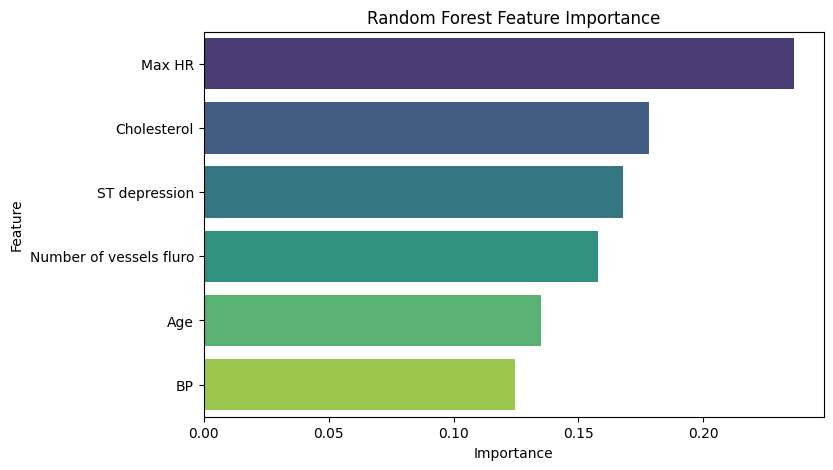

In [13]:
# -----------------------------
# Random Forest Classifier
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Define Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,           # number of trees
    random_state=42,
    class_weight="balanced",    # handle imbalanced classes
    max_depth=None,             # grow trees fully (can tune later)
    n_jobs=-1,
    verbose=1# use all cores
)

# 2️⃣ Train Random Forest
rf_model.fit(X_train, y_train)

# 3️⃣ Predict on test set
y_pred = rf_model.predict(X_test)

# 4️⃣ Evaluate Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Test Accuracy: {test_acc:.4f}")

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

# 6️⃣ Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# 7️⃣ Feature Importance
feature_importance = rf_model.feature_importances_
features_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=features_df, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
g